In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier
import joblib

In [2]:
train_transaction = pd.read_csv(r"C:\Users\admin\Downloads\ieee-fraud-detection/train_transaction.csv")
train_identity = pd.read_csv(r"C:\Users\admin\Downloads\ieee-fraud-detection/train_identity.csv")
df = pd.merge(train_transaction, train_identity, on="TransactionID", how="left")

print("Shape:", df.shape)

Shape: (590540, 434)


In [3]:
# Drop columns with too many missing values
threshold = len(df) * 0.7
df = df.dropna(thresh=threshold, axis=1)

# Fill remaining missing
df = df.fillna(0)

In [4]:
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [5]:
df_sample = df.sample(n=100000, random_state=42)

In [6]:
y = df_sample['isFraud']
X = df_sample.drop(['isFraud', 'TransactionID'], axis=1)

In [7]:
top_features = X.corrwith(y).abs().sort_values(ascending=False).head(10).index

print("Top 10 Features:", top_features)

X = X[top_features]

print("New Shape:", X.shape)   # (100000, 10)

Top 10 Features: Index(['V52', 'V51', 'V45', 'V40', 'V79', 'V74', 'addr2', 'V94', 'V43', 'V39'], dtype='object')
New Shape: (100000, 10)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

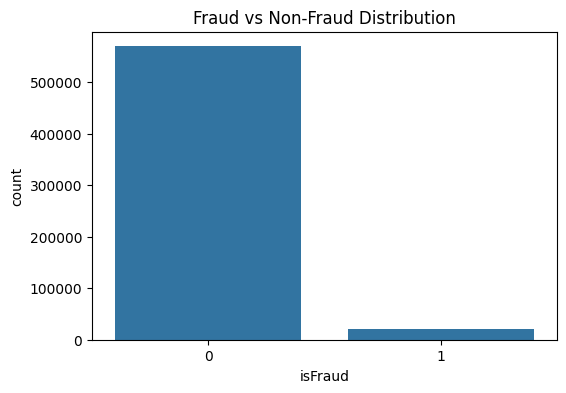

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=df['isFraud'])

plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

print(df['isFraud'].value_counts(normalize=True) * 100)

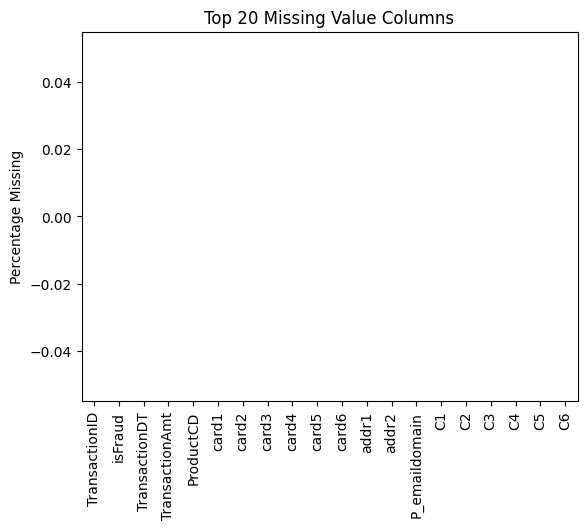

In [12]:
missing = df.isnull().mean().sort_values(ascending=False).head(20)

missing.plot(kind='bar')
plt.title("Top 20 Missing Value Columns")
plt.ylabel("Percentage Missing")
plt.show()

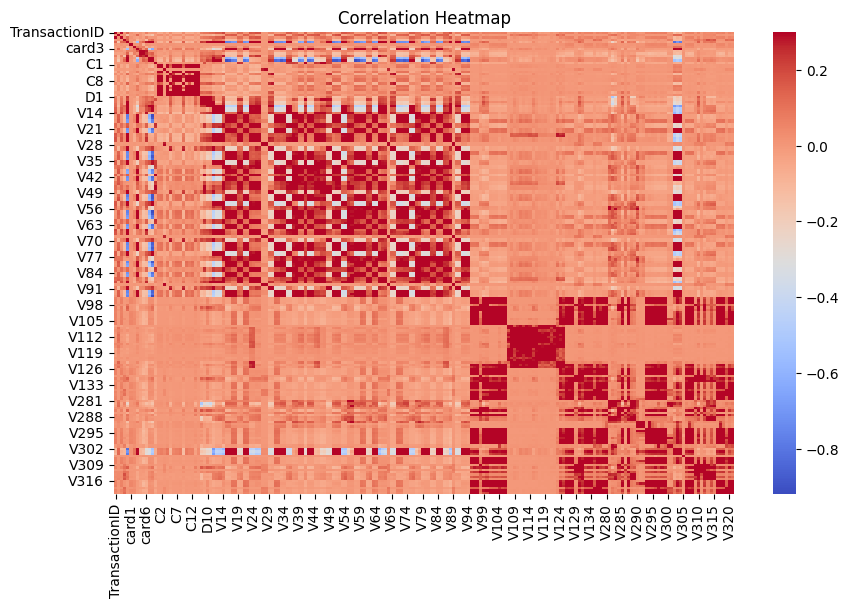

In [13]:
plt.figure(figsize=(10,6))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', vmax=0.3)
plt.title("Correlation Heatmap")
plt.show()

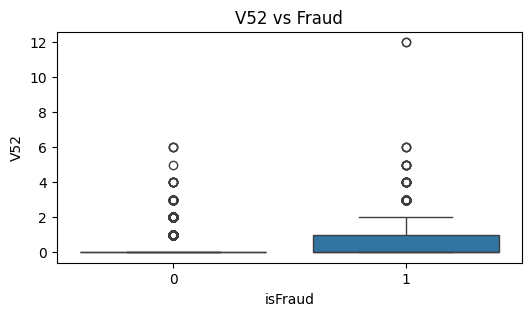

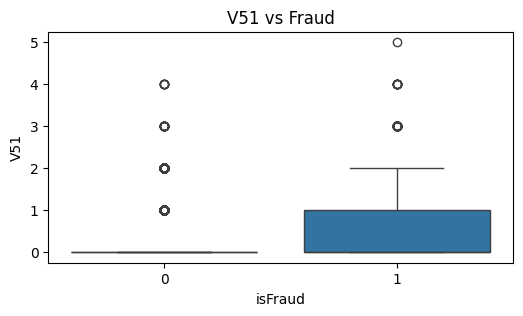

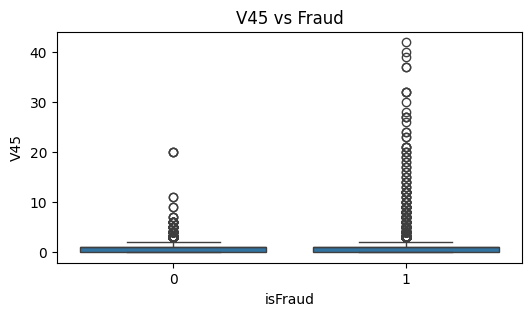

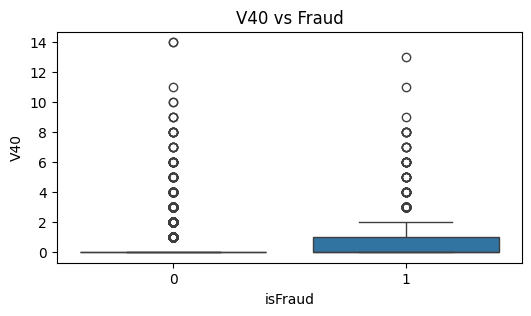

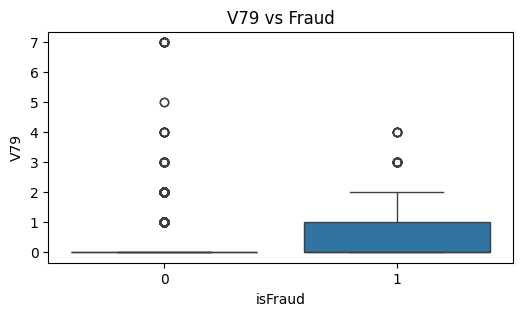

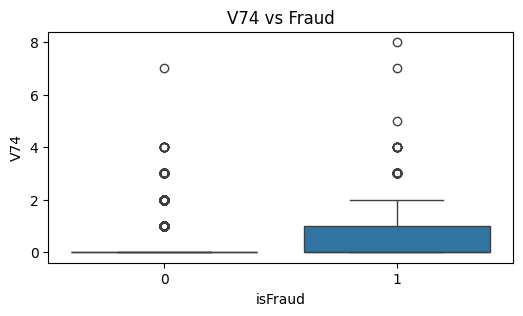

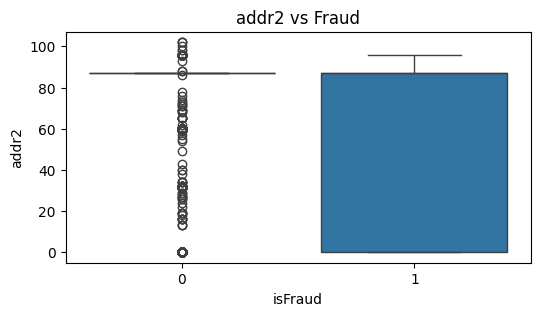

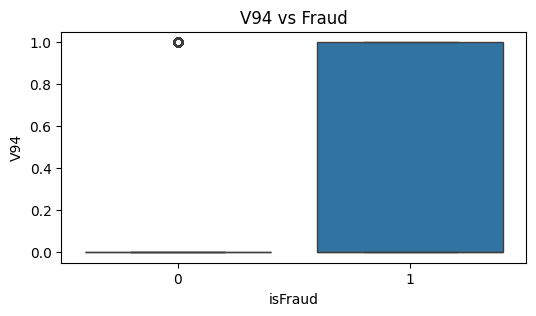

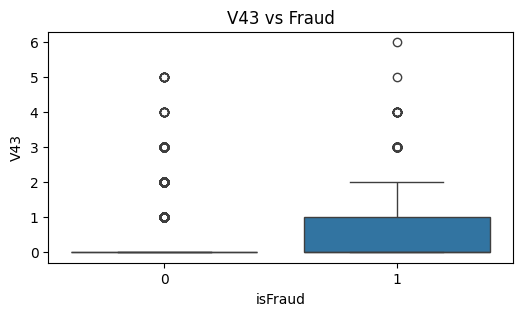

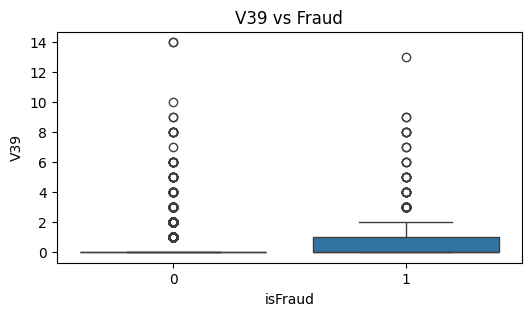

In [14]:
for col in top_features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} vs Fraud")
    plt.show()

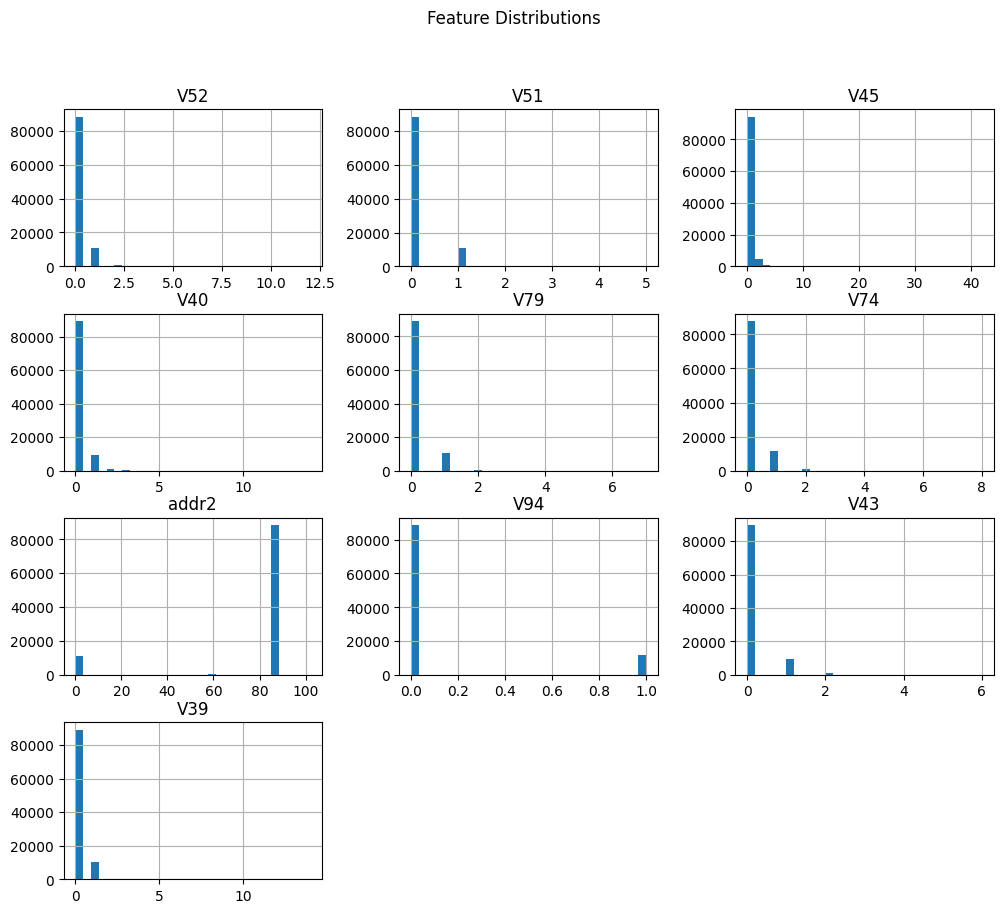

In [15]:
X.hist(figsize=(12,10), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

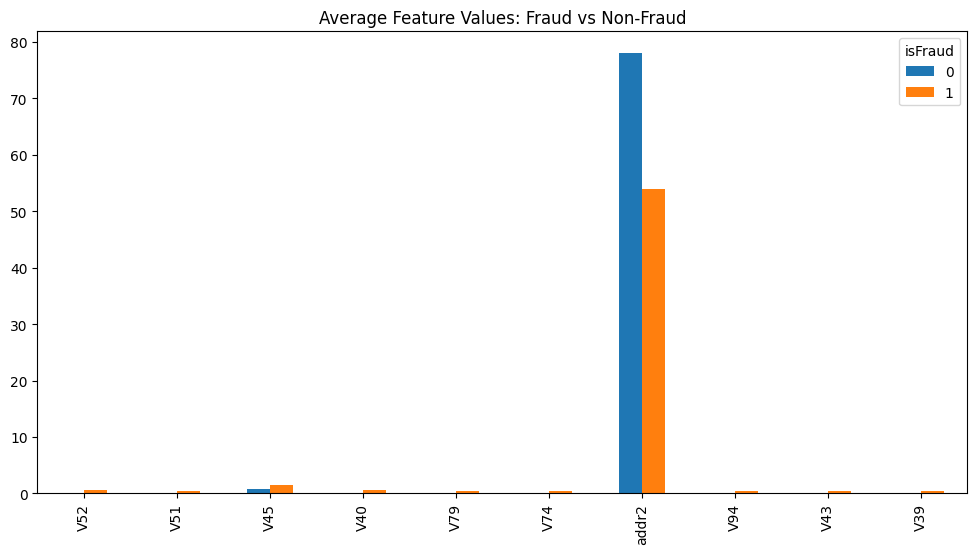

In [19]:
df.groupby('isFraud')[top_features].mean().T.plot(kind='bar', figsize=(12,6))
plt.title("Average Feature Values: Fraud vs Non-Fraud")
plt.show()

In [20]:
pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [21]:
model = XGBClassifier()

model.fit(X_train_pca, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [22]:
y_pred = model.predict(X_test_pca)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     19303
           1       0.67      0.13      0.22       697

    accuracy                           0.97     20000
   macro avg       0.82      0.57      0.60     20000
weighted avg       0.96      0.97      0.96     20000


Confusion Matrix:
 [[19257    46]
 [  604    93]]


In [23]:
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
joblib.dump(top_features, "features.pkl")

['features.pkl']

In [ ]:
from flask import Flask, request
import joblib
import numpy as np

app = Flask(__name__)

model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")
features = joblib.load("features.pkl")

@app.route('/')
def home():
    html = "<h2>💳 Fraud Detection (Top 10 Features)</h2>"
    html += "<form action='/predict' method='post'>"

    for f in features:
        html += f"{f}: <input name='{f}' type='number'><br>"

    html += "<button type='submit'>Predict</button></form>"
    return html


@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = [float(request.form[f]) for f in features]
        data = np.array(data).reshape(1, -1)

        scaled = scaler.transform(data)
        pca_data = pca.transform(scaled)

        prob = model.predict_proba(pca_data)[0][1]

        if prob > 0.3:
            return f"🚨 Fraud (Probability: {prob:.2f})"
        else:
            return f"✅ Legit (Probability: {prob:.2f})"

    except Exception as e:
        return str(e)


if __name__ == "__main__":
    app.run(debug=True, use_reloader=False, port=5000)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
